# Un videojuego de Datos!

Trabajamos para la tienda online Ice que vende videojuegos por todo el mundo. Las reseñas de usuarios y expertos, los géneros, las plataformas (por ejemplo, Xbox o PlayStation) y los datos históricos sobre las ventas de juegos están disponibles en fuentes abiertas. Vamos a identificar patrones que determinen si un juego tiene éxito o no. Esto nos permitirá detectar proyectos prometedores y planificar campañas publicitarias.

Delante de nosotros hay datos que se remontan a 2016. Imaginemos que es diciembre de 2016 y vamos a planear una campaña para 2017.

Lo importante es adquirir experiencia de trabajo con datos. Realmente no importa si estamos pronosticando las ventas de 2017 en función de los datos de 2016 o las ventas de 2027 en función de los datos de 2026.

El dataset contiene una columna "rating" que almacena la clasificación ESRB de cada juego. El Entertainment Software Rating Board (la Junta de clasificación de software de entretenimiento) evalúa el contenido de un juego y asigna una clasificación de edad como Adolescente o Adulto.

## Inicialización

In [560]:
# Vamos a cargar todas las librerías

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as st
import seaborn as sns



## Cargar datos

In [561]:
# Vamos a cargar los archivos de datos en un DataFrame

games = pd.read_csv('./datasets/games.csv')

## Preparar los datos

Explorando la tabla y realizando las correcciones necesarias

## Nuestro DataFrame: games

In [562]:
# Vamos a imprimir la información general sobre el DataFrame de juegos (games)

games.info()
games.head()

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  str    
 1   Platform         16715 non-null  str    
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  str    
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  str    
 10  Rating           9949 non-null   str    
dtypes: float64(6), str(5)
memory usage: 1.4 MB


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [563]:
# Vamos a imprimir una muestra de los datos del DataFrame de juegos (games)

games.sample(5)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
6137,Shrek the Third,Wii,2007.0,Action,0.25,0.01,0.00,0.02,57.0,6.7,E10+
5282,Bloody Roar 3,PS2,2001.0,Fighting,0.15,0.11,0.05,0.04,71.0,8.6,T
9988,Cabela's North American Adventures,PS3,2010.0,Sports,0.11,0.00,0.00,0.01,NaN,tbd,T
8405,Backyard Wrestling: Don't Try This at Home,XB,2003.0,Fighting,0.13,0.04,0.00,0.01,50.0,5,M
15760,Castle Shikigami 2,PS2,2004.0,Shooter,0.01,0.01,0.00,0.00,67.0,7.4,E


Nuestro DataFrame necesita un poco de limpieza y organización

- El año se muestra en tipo float, lo cual es innecesario. Vamos a pasarlo a int

- El user_score está en str, al ser un puntaje lo ideal es que esté en tipo float (al igual que critic_score)

- Además, vamos a organizar los nombres de nuestras columnas siguiendo la convencion snake_case

- Finalmente, hay unos valores denominados 'tbd' (to be defined) que nos puede afectar al cruzar columnas numéricas para nuestro análisis

## Corregir datos

Vamos a proceder a corregir los items que encontramos en nuestro análisis preliminar

In [564]:
games.columns = games.columns.str.lower()
games['year_of_release'] = games['year_of_release'].astype('Int64')
games['user_score'] = pd.to_numeric(games['user_score'], errors='coerce')

games.info()

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  str    
 1   platform         16715 non-null  str    
 2   year_of_release  16446 non-null  Int64  
 3   genre            16713 non-null  str    
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   str    
dtypes: Int64(1), float64(6), str(4)
memory usage: 1.4 MB


## Enriquecer los datos

Al convertir la columna user_score a tipo numérico a través de to_numeric, los valores 'tbd' (str en general) se convierten en NaN automáticamente

También vamos a convertir la escala de user_score de 0 a 10 a 0 a 100 para nivelarla con critic_score y que estén en un mismo rango para poder hacer gráficos y comparativas

Nuestros valores 'tbd' ahora son NaN, vamos a reemplazarlos por la mediana en nuestras categorías de score. La mediana es mucho más robusta para nivelar puntajes, mucho más adecuada en estos casos que el promedio, el cual puede estar sesgado por valores extremos.

Nuestros NaN en la columna rating vamos a reemplazarlos por 'Not Rated'

Vamos a confirmar que no hayan duplicados explícitos en todo el DataFrame

In [565]:
# Convertir los valores de user_score de 0 a 100
games['user_score'] = games['user_score'] * 10

# Reemplazamos valores NaN en las columnas 'user_score' y 'critic_score' con la mediana de cada columna
games['user_score'] = games['user_score'].fillna(games['user_score'].median())
games['critic_score'] = games['critic_score'].fillna(games['critic_score'].median())

# Reemplazamos valores NaN en la columna 'rating' con 'Not Rated'
games['rating'] = games['rating'].fillna('Not Rated')

# Confirmamos que no hayan duplicados explicitamente en el DataFrame
print(f'Número de filas duplicadas: {games.duplicated().sum()}')

# Creamos la columna total_sales
games['total_sales'] = games['na_sales'] + games['eu_sales'] + games['jp_sales'] + games['other_sales']


# Finalmente mostramos las primeras filas del DataFrame para verificar los cambios realizados
games.info()
games.head()


Número de filas duplicadas: 0
<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  str    
 1   platform         16715 non-null  str    
 2   year_of_release  16446 non-null  Int64  
 3   genre            16713 non-null  str    
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     16715 non-null  float64
 9   user_score       16715 non-null  float64
 10  rating           16715 non-null  str    
 11  total_sales      16715 non-null  float64
dtypes: Int64(1), float64(7), str(4)
memory usage: 1.5 MB


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,80.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,71.0,75.0,Not Rated,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,83.0,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,80.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,71.0,75.0,Not Rated,31.38


# Analizando datos de nuestros videojuegos

## Número de videojuegos lanzados por año/década

Vamos a analizar la cantidad de videojuegos lanzado por año. Vamos a mostrar los primeros años y los últimos

In [566]:
# Agrupamos por fecha de lanzamiento y contamos el número de juegos por año
games_per_year = games.groupby('year_of_release').size()
# Renombrar la columna 'name' a 'number_of_games'

print(f'Número de juegos por año de lanzamiento (Primeros 10 años):\n{games_per_year.head(10)}')
print(f'Número de juegos por año de lanzamiento (Últimos 10 años):\n{games_per_year.tail(10)}')


Número de juegos por año de lanzamiento (Primeros 10 años):
year_of_release
1980     9
1981    46
1982    36
1983    17
1984    14
1985    14
1986    21
1987    16
1988    15
1989    17
dtype: int64
Número de juegos por año de lanzamiento (Últimos 10 años):
year_of_release
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
dtype: int64


/var/folders/wd/98_pqg_n31gbj0qbndfcm0c80000gn/T/ipykernel_38764/234101039.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


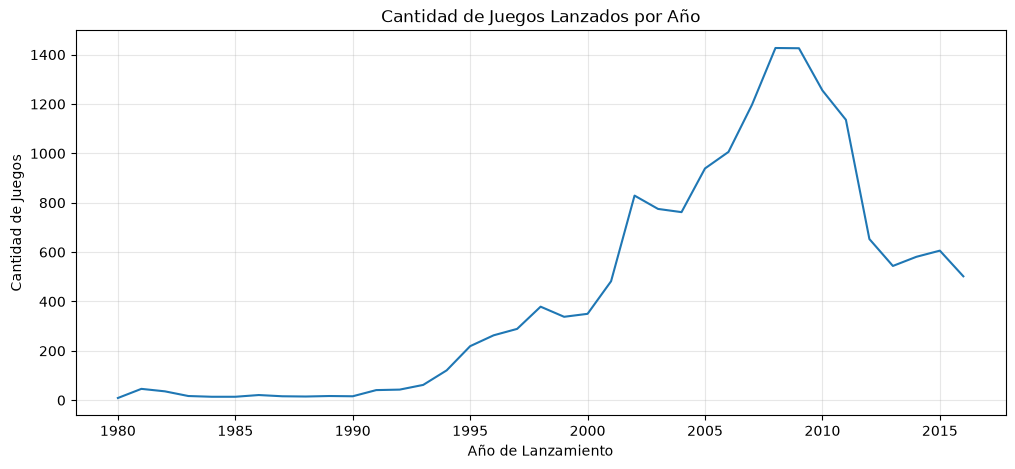

In [567]:
games_per_year.plot(figsize=(12, 5), title='Cantidad de Juegos Lanzados por Año')
plt.legend().remove()
plt.xlabel('Año de Lanzamiento')
plt.ylabel('Cantidad de Juegos')
plt.grid(alpha=0.3)
plt.show()



¡Vea Pues! La cantidad de videojuegos que salen en los últimos años supera ampliamente la cantidad de lanzamientos de los primeros años, incluso aunque los lanzamientos hayan caído notablemente a partir de 2012, hemos pasado de algunos números y decenas a cientos y más de mil lanzamientos por año.

Un conteo de lanzamientos de videojuegos por año puede ser muy extenso, ¿qué tal si agrupamos por décadas?

In [568]:
# Agrupamos por década de lanzamiento y contamos el número de juegos por década
games['decade'] = (games['year_of_release'] // 10) * 10

print(games['decade'].value_counts().sort_index())

decade
1980     205
1990    1771
2000    9193
2010    5277
Name: count, dtype: Int64


¡Ahora vemos unas diferencias incluso más impresionantes! La década (completa) con mayor número de lanzamientos fue en los años 2000s y aumento casi x50 veces en comparación a la década de 1980.

Para la última década (2010-) se han lanzado más de la mitad de videojuegos que en la década anterior, pero tengamos en cuenta que esta tabla solo tiene información hasta el año 2016. Sin embargo, en la información de la tabla se muestra que el número de lanzamientos por año se ha reducido

## Analizando ventas por plataformas

Ahora vamos a analizar las ventas por plataformas

In [569]:
# Ventas por plataforma
sales_by_platform = games.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print(f'Ventas totales por plataforma:\n{sales_by_platform}')



Ventas totales por plataforma:
platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
3DS      259.00
XB       257.74
GB       255.46
NES      251.05
N64      218.68
SNES     200.04
GC       198.93
XOne     159.32
2600      96.98
WiiU      82.19
PSV       54.07
SAT       33.59
GEN       30.77
DC        15.95
SCD        1.86
NG         1.44
WS         1.42
TG16       0.16
3DO        0.10
GG         0.04
PCFX       0.03
Name: total_sales, dtype: float64


Ahora podemos ver el número total de ventas de cada plataforma a lo largo de la historia. Los juegos de PS2 han generado la mayor cantidad de ventas (1255.77 millones de USD), seguida por X360 (971.42 millones de USD) y PS3 (939.65 millones de USD)

¿Qué tal si nos enfocamos en las 10 más relevantes y hacemos un gráfico de barras?

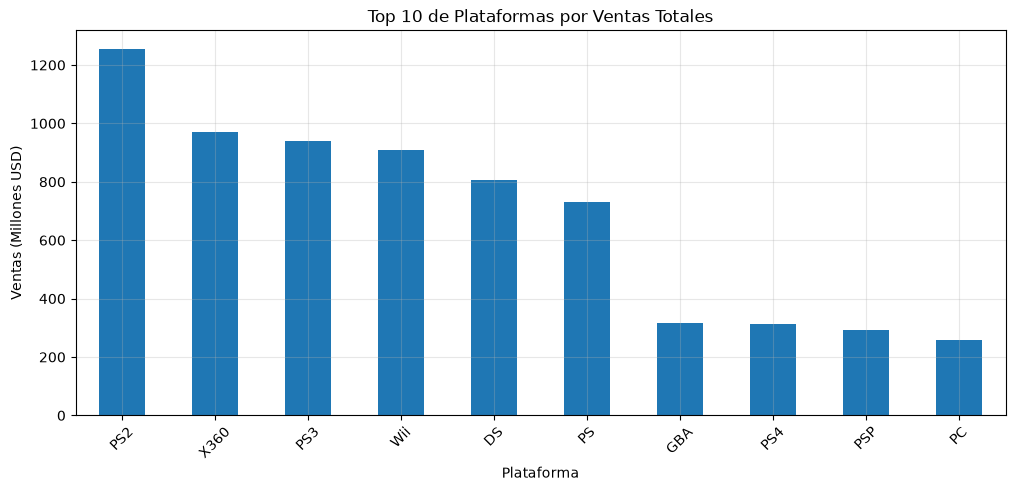

In [570]:
# Graficamos el total de ventas por plataforma
sales_by_platform.head(10).plot(kind='bar', figsize=(12, 5), title='Top 10 de Plataformas por Ventas Totales')
plt.xlabel('Plataforma')
plt.ylabel('Ventas (Millones USD)')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

Ahora podemos ver las 10 plataformas principales que más ventas de videojuegos han generado en la historia.

Vamos a tomar las 10 plataformas principales y vamos a filtrar nuestro DataFrame para trabajar sobre eso

In [571]:
# Filtrar DataFrame con las 10 plataformas con mayores ventas
top_10_platforms = sales_by_platform.head(10).index
games_top_10_platforms = games[games['platform'].isin(top_10_platforms)]

# Filtrarlas por año de lanzamiento y ventas totales
platforms_filtered = games_top_10_platforms.groupby(['platform', 'year_of_release'])['total_sales'].sum().unstack().fillna(0)

# Vamos a reindexar el DataFrame para que las plataformas estén orden por ventas totales
platforms_filtered = platforms_filtered.reindex(top_10_platforms)

display(platforms_filtered)

year_of_release,1985,1988,1992,1994,1995,1996,1997,1998,1999,2000,...,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
platform,,,,,,,,,,,,,,,,,,,,,
PS2,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,39.17,...,75.99,53.90,26.40,5.64,0.45,0.00,0.00,0.00,0.00,0.00
X360,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,95.41,135.26,120.29,170.03,143.84,99.74,88.58,34.74,11.96,1.52
PS3,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,73.19,118.52,130.93,142.17,156.78,107.36,113.25,47.76,16.82,3.60
Wii,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,152.77,171.32,206.97,127.95,59.65,21.71,8.59,3.75,1.14,0.18
DS,0.02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,146.94,145.31,119.54,85.02,26.18,11.01,1.54,0.00,0.00,0.00
PS,0.00,0.00,0.00,6.03,35.96,94.70,136.17,169.49,144.53,96.37,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
GBA,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.07,...,3.40,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
PS4,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,25.99,100.00,118.90,69.25
PSP,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,46.93,34.55,37.78,35.04,17.82,7.69,3.14,0.24,0.12,0.00


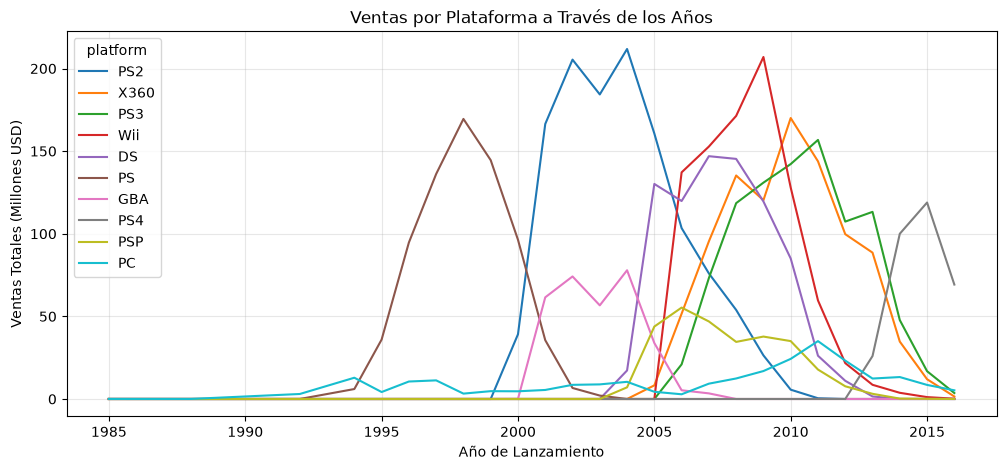

In [572]:
# Grafico de ventas por plataforma a través de los años
platforms_filtered.T.plot(figsize=(12, 5), title='Ventas por Plataforma a Través de los Años')
plt.xlabel('Año de Lanzamiento')
plt.ylabel('Ventas Totales (Millones USD)')
plt.grid(alpha=0.3)
plt.show()



Esto nos da información muy valiosa

- Primero hay que tener en cuenta que las compañías lanzan consolas a través de los años y a esto le llamamos "generaciones". Por ejemplo, PS sale en el año 1994, PS2 en el año 2000, PS3 en el año 2006 y PS4 en 2013.

- Las compañías lanzan generaciones de sus nuevas consolas cada 6-8 años. Sin embargo, las plataformas tienen un tiempo útil alrededor de 10 años

- PC tiene las menores ventas pero también ha sido la más constante, ya que no es una plataforma exclusivamente de videojuegos y no maneja ese tipo de estructura como las demás compañías

- Es interesante ver que muchas tienen picos en forma de "M" lo que indica que alcanzan su primer pico en los primeros años de lanzamiento, caen un poco porque se pierde el factor "novedad" y luego son reimpulsadas con videojuegos nuevos hacia el final de su generación

- Las ventas de videojuegos para consolas de mesa son mayores que las de las consolas portátiles, excepto por PC. No sería justo el nivel de ventas de PS4 en esta conclusión pues su lanzamiento es en 2013 y aún no se puede medir toda su vida útil

- La caída de ventas se solapa con el lanzamiento de una nueva generación

## Reorganizando nuestro DataFrame

Teniendo en cuenta las conclusiones anteriores, vamos a tomar el rango 2006-2016 que abarca el ciclo de vida útil de la mayoría de consolas (lanzamiento, auge y declive) para continuar con nuestro análisis y poder construir modelos e hipótesis para el año 2017

También vamos a volver a filtrar las plataformas que más ventas tuvieron en nuestro nuevo período (2006-2016)

In [573]:
# Filtrando los juegos lanzados entre 2006 y 2016
games = games[(games['year_of_release'] >= 2006) & (games['year_of_release'] <=2016)]

display(games.head())

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales,decade
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,80.0,E,82.54,2000
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,83.0,E,35.52,2000
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,80.0,E,32.77,2000
6,New Super Mario Bros.,DS,2006,Platform,11.28,9.14,6.50,2.88,89.0,85.0,E,29.80,2000
7,Wii Play,Wii,2006,Misc,13.96,9.18,2.93,2.84,58.0,66.0,E,28.91,2000


In [574]:
sales_by_platform = games.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print(f'Top 12 Ventas totales por plataforma (2006-2016):\n{sales_by_platform.head(12)}')



Top 12 Ventas totales por plataforma (2006-2016):
platform
X360    952.99
PS3     931.34
Wii     891.18
DS      655.35
PS4     314.14
PS2     265.80
3DS     257.81
PSP     238.63
PC      163.42
XOne    159.32
WiiU     82.19
PSV      53.81
Name: total_sales, dtype: float64


Tomamos las primeras 12 posiciones para incluir lanzamientos recientes de plataformas como WiiU y PSV

In [575]:
# Filtrar DataFrame con las 12 plataformas con mayores ventas (2006-2016)
top_12_platforms = sales_by_platform.head(12).index
games_top_12_platforms = games[games['platform'].isin(top_12_platforms)]

# Filtrarlas por año de lanzamiento y ventas totales
platforms_filtered = games_top_12_platforms.groupby(['platform', 'year_of_release'])['total_sales'].sum().unstack().fillna(0)

# Vamos a reindexar el DataFrame para que las plataformas estén orden por ventas totales
platforms_filtered = platforms_filtered.reindex(top_12_platforms)

display(platforms_filtered)

year_of_release,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
platform,,,,,,,,,,,
X360,51.62,95.41,135.26,120.29,170.03,143.84,99.74,88.58,34.74,11.96,1.52
PS3,20.96,73.19,118.52,130.93,142.17,156.78,107.36,113.25,47.76,16.82,3.60
Wii,137.15,152.77,171.32,206.97,127.95,59.65,21.71,8.59,3.75,1.14,0.18
DS,119.81,146.94,145.31,119.54,85.02,26.18,11.01,1.54,0.00,0.00,0.00
PS4,0.00,0.00,0.00,0.00,0.00,0.00,0.00,25.99,100.00,118.90,69.25
PS2,103.42,75.99,53.90,26.40,5.64,0.45,0.00,0.00,0.00,0.00,0.00
3DS,0.00,0.00,0.00,0.00,0.00,63.20,51.36,56.57,43.76,27.78,15.14
PSP,55.32,46.93,34.55,37.78,35.04,17.82,7.69,3.14,0.24,0.12,0.00
PC,2.85,9.28,12.42,16.91,24.28,35.03,23.22,12.38,13.28,8.52,5.25


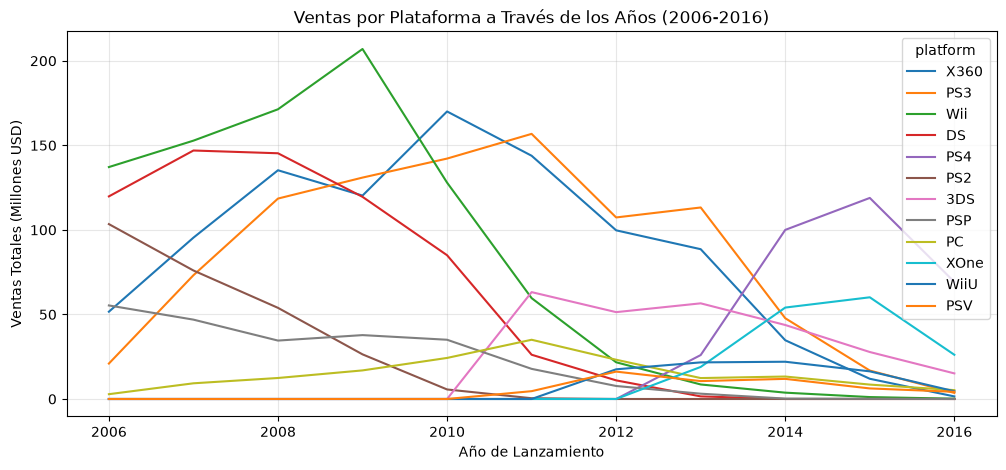

In [576]:
# Grafico de ventas por plataforma a través de los años 2006-2016
platforms_filtered.T.plot(figsize=(12, 5), title='Ventas por Plataforma a Través de los Años (2006-2016)')
plt.xlabel('Año de Lanzamiento')
plt.ylabel('Ventas Totales (Millones USD)')
plt.grid(alpha=0.3)
plt.show()

## ¿Quiénes van de subida y quiénes van de bajada?

Los lanzamientos más recientes son: 3DS (2011), PSV (2011), WiiU (2012), XOne (2013) y PS4 (2013) y son las plataformas que tienen más potencial de crecimiento, a pesar de que podemos ver un decrecimiento a partir de 2015 en las ventas de manera generalizada en todo el sector

Debemos entender que aunque los líderes en ventas de videojuegos de este fragmento de tiempo 2006-2016 son X360, PS3 y Wii, al ser un modelo por "generaciones", estas mismas plataformas ya han acumulado sus picos de ventas máximas y se encuentran actualmente en declive, mientras que los lanzamientos más recientes anteriormente mencionados se encuentra en su etapa lanzamiento-auge

## Viendo las ventas globales de todos los videojuegos por Plataformas

A continuación decidimos generar dos boxplots, debido a que las ventas de todos los videojuegos nos muestra valores atípicos (outliers) muy lejanos a nuestras cajas. Veremos un gráfico de caja generalizado y otro acotado o en "zoom" para centrarnos en nuestras cajas y bigotes

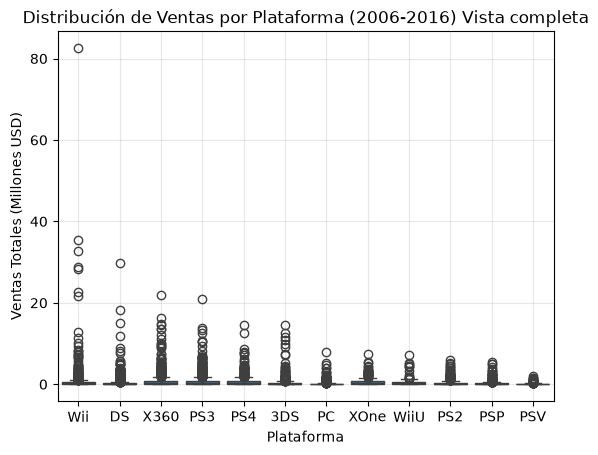

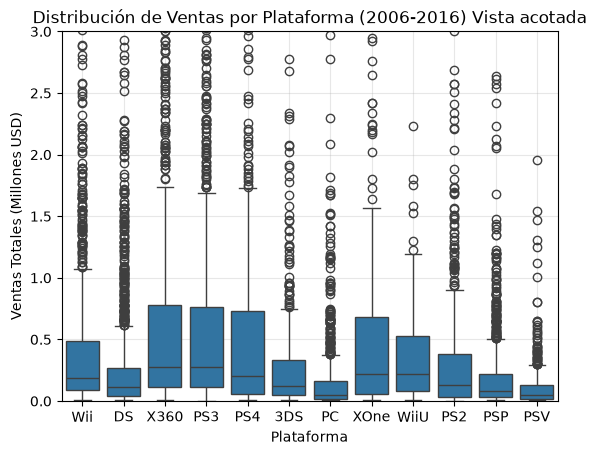

In [577]:
# Grafico de caja de ventas por plataforma a través de los años 2006-2016
sns.boxplot(data=games_top_12_platforms, x='platform', y='total_sales')
plt.title('Distribución de Ventas por Plataforma (2006-2016) Vista completa')
plt.xlabel('Plataforma')
plt.ylabel('Ventas Totales (Millones USD)')
plt.grid(alpha=0.3)
plt.show()

sns.boxplot(data=games_top_12_platforms, x='platform', y='total_sales')
plt.ylim(0, 3)  # Limitar el eje y para una mejor visualización
plt.title('Distribución de Ventas por Plataforma (2006-2016) Vista acotada')
plt.xlabel('Plataforma')
plt.ylabel('Ventas Totales (Millones USD)')
plt.grid(alpha=0.3)
plt.show()


En nuestra vista generalizada podemos observar valores atípicos incluso por encima de 80 millones de USD en la consola Wii y de entre 20 y 30 millones en consolas como DS, X360 y PS3. Al mismo tiempo, nuestras cajas y bigotes presentan mínimos cercanos a 0 y máximos alrededor de 1.7 millones de USD. ¿Cómo se explican estos valores atípicos tan lejanos frente a sus cajas? La existencia de videojuegos con éxitos masivos en ventas como Wii Sports, Mario (Wii) o GTA están representados en dichos outliers.

También podemos observar que las medianas más altas corresponden a X360 y PS3, seguidos de PS4, XOne y WiiU. Es importante recordar que PS4, XOne y WiiU fueron lanzadas en 2013 y corresponden a la nueva generación de plataformas, llevando apenas 3 años en el mercado, mientras que X360 y PS3 llevan toda o casi toda su vida útil en nuestro rango de 2006-2016. Aunque sus medianas son relativamente cercanas, el potencial de crecimiento de las plataformas lanzadas en 2013 se encuentra en auge, mientras que X360 y PS3 ya vienen en declive.

- Para efectos del ejercicio, vamos a ver estos mismos datos a través de un Histograma para observar la distribución:

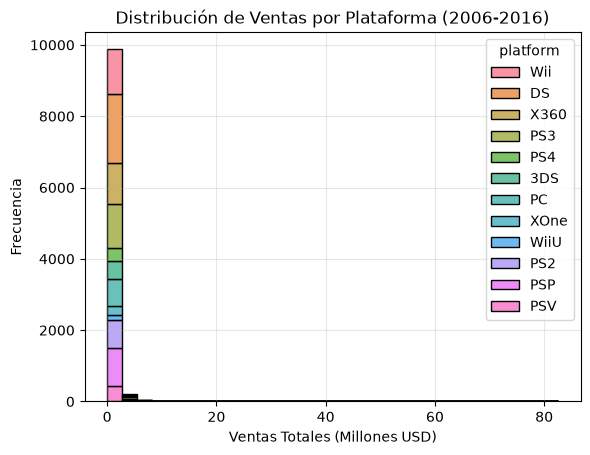

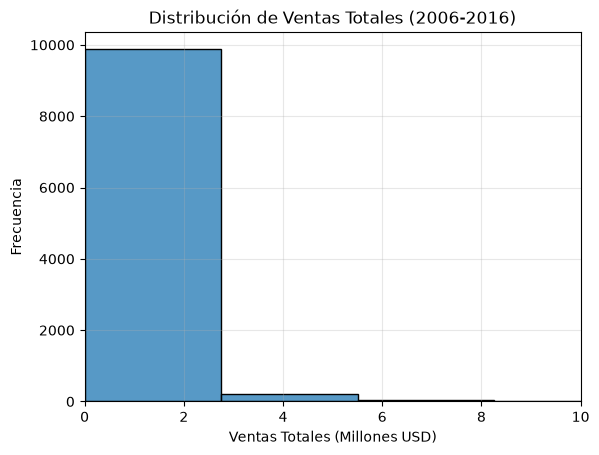

In [618]:
# Histograma por plataforma a través de los años 2006-2016
sns.histplot(data=games_top_12_platforms, x='total_sales', hue='platform', multiple='stack', bins=30)
plt.title('Distribución de Ventas por Plataforma (2006-2016)')
plt.xlabel('Ventas Totales (Millones USD)')
plt.ylabel('Frecuencia')
plt.grid(alpha=0.3)
plt.show()

# Histograma de Ventas Totales a través de los años 2006-2016
sns.histplot(data=games_top_12_platforms, x='total_sales', bins=30)
plt.title('Distribución de Ventas Totales (2006-2016)')
plt.xlabel('Ventas Totales (Millones USD)')
plt.xlim(0, 10)  # Limitar el eje x para una mejor visualización
plt.ylabel('Frecuencia')
plt.grid(alpha=0.3)
plt.show()

Como podemos ver en el primer histograma, los valores se concentran cerca a cero y no nos da mucha información clara ni relevante sobre las plataformas o sus ventas totales, además de mostrar un sesgo hacia la derecha.

En el segundo histograma, eliminamos la segmentación por plataforma y dejamos solo la distribución de las Ventas Totales en el período 2006-2016. Esto se ve mucho más limpio y aún nos muestra el sesgo a la derecha. Se aplicó un límite sobre el eje x para acotar el gráfico.

Podemos concluir que un histograma no siempre es la mejor opción cuando hay muchos representantes de una misma categoría a ser evaluados (en este caso las 12 plataformas) y un Boxplot nos puede dar una vista más organizada y limpia para obtener información relevante.

## Evaluando correlaciones - Ventas de videojuegos de PS3 y sus puntajes

Vamos a evaluar la correlación de la consola PS3 con los puntajes de usuario y de la crítica para definir si dichos puntajes afectan las ventas totales de los videojuegos. Para ello vamos a generar un gráfico de dispersión y un cálculo de correlación de la consola, para cada tipo de puntaje (usuario y crítica)

### Ventas totales vs Puntuación de usuario

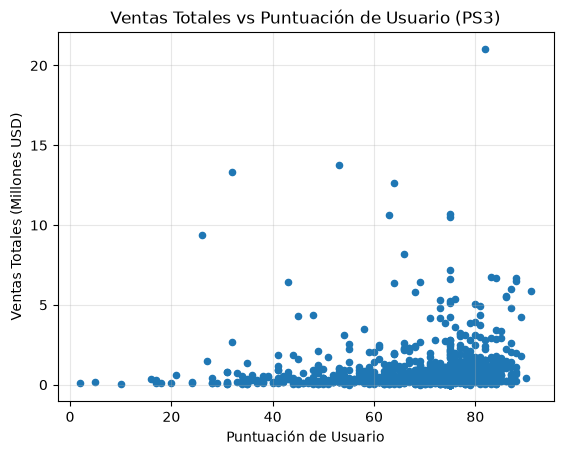

In [578]:
# Definimos un DataFrame para los juegos de PS3
ps3_games = games_top_12_platforms[games_top_12_platforms['platform'] == 'PS3']

# Gráfico de dispersión de ventas totales vs puntuación de usuario para juegos de PS3
ps3_games.plot(kind='scatter', x='user_score', y='total_sales')
plt.title('Ventas Totales vs Puntuación de Usuario (PS3)')
plt.xlabel('Puntuación de Usuario')
plt.ylabel('Ventas Totales (Millones USD)')
plt.grid(alpha=0.3)
plt.show()

In [579]:
correlacion = ps3_games['user_score'].corr(ps3_games['total_sales'])
print(f'Correlación entre Puntuación de Usuario y Ventas Totales para PS3: {correlacion}')

Correlación entre Puntuación de Usuario y Ventas Totales para PS3: 0.04201840525930171


### Ventas totales vs Puntuación de la crítica

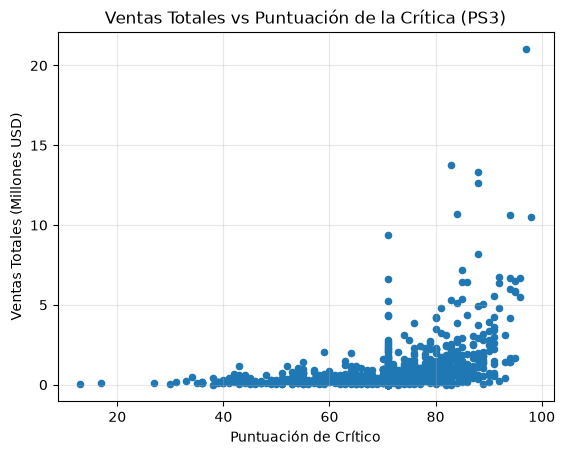

In [580]:
# Gráfico de dispersión de ventas totales vs puntuación de la crítica para juegos de PS3
ps3_games.plot(kind='scatter', x='critic_score', y='total_sales')
plt.title('Ventas Totales vs Puntuación de la Crítica (PS3)')
plt.xlabel('Puntuación de Crítico')
plt.ylabel('Ventas Totales (Millones USD)')
plt.grid(alpha=0.3)
plt.show()

In [581]:
correlacion = ps3_games['critic_score'].corr(ps3_games['total_sales'])
print(f'Correlación entre Puntuación de la Crítica y Ventas Totales para PS3: {correlacion}')

Correlación entre Puntuación de la Crítica y Ventas Totales para PS3: 0.3986608611186779


Nos hemos planteado si los puntajes, tanto de usuarios como de la crítica, pueden influir en el éxito en ventas o no de los videojuegos en la plataforma de PS3. 

A partir de nuestros gráficos y nuestros valores de correlación podemos concluir que los puntajes de los usuarios en relación a las ventas de videojuegos tienen una correlación cercana a 0 (0.0420) mientras que el puntaje de la crítica maneja una correlación mucho más alta en comparación con la de los usuarios, aunque no sustancialmente alta en su valor (0.39). Podemos concluir que el puntaje de la crítica puede afectar de una forma moderada las ventas de un videojuego, mientras que los puntajes de los usuarios tienen muy baja influencia en el éxito en ventas o no de un videojuego.

## Top 20 Juegos más vendidos por plataforma

Ahora vamos a hacer una tabla que nos permite ver las ventas de los videojuegos en cada una de las diferentes plataformas. Agregamos una columna que nos muestre el total de ventas de todas las plataformas y tomamos los 20 videojuegos con mayores ventas totales

In [582]:
# Creamos una tabla pivote para analizar las ventas por juego y plataforma
games_by_platform = games_top_12_platforms.pivot_table(index='name', columns='platform', values='total_sales', aggfunc='sum')
games_by_platform['Total'] = games_by_platform.sum(axis=1)
display(games_by_platform.sort_values('Total', ascending=False).head(20))



platform,3DS,DS,PC,PS2,PS3,PS4,PSP,PSV,Wii,WiiU,X360,XOne,Total
name,,,,,,,,,,,,,
Wii Sports,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,82.54,NaN,NaN,NaN,82.54
Grand Theft Auto V,NaN,NaN,1.17,NaN,21.05,12.62,NaN,NaN,NaN,NaN,16.27,5.47,56.58
Mario Kart Wii,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.52,NaN,NaN,NaN,35.52
Wii Sports Resort,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.77,NaN,NaN,NaN,32.77
Call of Duty: Modern Warfare 3,NaN,NaN,1.71,NaN,13.33,NaN,NaN,NaN,0.83,NaN,14.73,NaN,30.60
New Super Mario Bros.,NaN,29.80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.80
Call of Duty: Black Ops II,NaN,NaN,1.52,NaN,13.79,NaN,NaN,NaN,NaN,0.41,13.68,NaN,29.40
Call of Duty: Black Ops,NaN,0.58,NaN,NaN,12.63,NaN,NaN,NaN,1.37,NaN,14.62,NaN,29.20
Wii Play,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.91,NaN,NaN,NaN,28.91


Podemos ver que las ventas de videojuegos están relacionadas entre generaciones principalmente (PS3, X360 - PS4 y XOne) 

- Nintendo maneja valores altos en videojuegos exclusivos de su plataforma. Juegos como Wii Sports o Mario Kart Wii, al mostrar valores NaN en todas las columnas excepto Wii nos confirma que es un juego exclusivo de la plataforma

- Juegos como Call of Duty: Ghosts o The Elder Scrolls V: Skyrim nos muestra valores de ventas relacionados entre PS3 y X360 (6.40 y 8.79, respectivamente) y entre PS4 y XOne (1.32 y 0.75, respectivamente)

## Analizando por Géneros

Ahora vamos a tomar nuestro DataFrame y lo vamos a agrupar por géneros y ventas totales, vamos a sumar las ventas totales por género y vamos a sacar la mediana. Esto nos permitirá saber cuántos millones de USD produce cada género y lo complementamos con el valor de la mediana de los videojuegos por cada género

In [583]:
# Calculamos la suma y la mediana de ventas por género para los juegos de las 12 plataformas principales
games_by_genre_sum = games_top_12_platforms.groupby('genre')['total_sales'].sum()
games_by_genre_median = games_top_12_platforms.groupby('genre')['total_sales'].median()

print(f'Suma de ventas por género:\n{games_by_genre_sum.sort_values(ascending=False)}')
print(f'Mediana de ventas por género:\n{games_by_genre_median.sort_values(ascending=False)}')

Suma de ventas por género:
genre
Action          1106.55
Sports           787.90
Shooter          715.78
Misc             552.76
Role-Playing     520.97
Racing           294.24
Platform         277.13
Simulation       220.14
Fighting         187.92
Adventure        139.65
Puzzle            89.84
Strategy          73.10
Name: total_sales, dtype: float64
Mediana de ventas por género:
genre
Shooter         0.31
Platform        0.24
Sports          0.21
Racing          0.17
Action          0.17
Fighting        0.16
Role-Playing    0.15
Misc            0.13
Simulation      0.13
Puzzle          0.08
Strategy        0.07
Adventure       0.04
Name: total_sales, dtype: float64


- En las primeras posiciones de la suma de ventas por género encontramos nombres que se repiten también en el cálculo de la mediana de ventas. El género de acción está en primer lugar con 1106.55 millones de USD y la mediana de los videojuegos de este género está en quinto lugar con 0.17. Que la mediana esté más abajo que la suma total del género nos indica seguramente que hay muchos más juegos de este género, que de otros géneros en el top

- Valores interesantes como Sports, que venden en total 787.90 millones de USD, toman un valor interesante cuando consideramos que el valor de la mediana es de 0.21 millones, pero además, solo Wii Sports representa 82.54 millones de USD (más del 10%) si nos referimos a nuestra tabla pivote generada anteriormente

- Géneros como Adventure, Puzzle o Strategy están de últimos tanto en la suma de ventas total de videojuegos por género como en la mediana de sus ventas

## Creando perfiles de usuario para cada region

A continuación vamos a analizar las ventas totales de cada region (NA, EU y JP). Vamos a analizar sus ventas por plataforma, por género y como afectan las clasificaciones ESRB (Rating) a las ventas de cada region

### Por Plataformas

In [584]:
# Analizamos las ventas en Norteamérica por sus 5 plataformas principales
platforms_in_na = games_top_12_platforms.groupby('platform')['na_sales'].sum().sort_values(ascending=False).head()
platforms_in_na = platforms_in_na.rename_axis('Platform').reset_index(name='NA Sales')

# Calculamos la cuota de mercado de cada plataforma en Norteamérica
platforms_in_na['Cuota'] = (platforms_in_na['Platform'].map(games_top_12_platforms.groupby('platform')['na_sales'].sum()) / games_top_12_platforms['na_sales'].sum()) * 100

display(platforms_in_na)

# Analizamos las ventas en Europa por sus 5 plataformas principales
platforms_in_eu = games_top_12_platforms.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).head()
platforms_in_eu = platforms_in_eu.rename_axis('Platform').reset_index(name='EU Sales')

# Calculamos la cuota de mercado de cada plataforma en Europa
platforms_in_eu['Cuota'] = (platforms_in_eu['Platform'].map(games_top_12_platforms.groupby('platform')['eu_sales'].sum()) / games_top_12_platforms['eu_sales'].sum()) * 100

display(platforms_in_eu)

# Analizamos las ventas en Japón por sus 5 plataformas principales
platforms_in_jp = games_top_12_platforms.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).head()
platforms_in_jp = platforms_in_jp.rename_axis('Platform').reset_index(name='JP Sales')

# Calculamos la cuota de mercado de cada plataforma en Japón
platforms_in_jp['Cuota'] = (platforms_in_jp['Platform'].map(games_top_12_platforms.groupby('platform')['jp_sales'].sum()) / games_top_12_platforms['jp_sales'].sum()) * 100

display(platforms_in_jp)

,Platform,NA Sales,Cuota
0,X360,588.84,24.900308
1,Wii,486.87,20.588297
2,PS3,390.13,16.497448
3,DS,323.99,13.700582
4,PS2,114.89,4.858360


,Platform,EU Sales,Cuota
0,PS3,327.21,21.969692
1,X360,267.89,17.986800
2,Wii,258.32,17.344246
3,DS,142.99,9.600704
4,PS4,141.09,9.473133


,Platform,JP Sales,Cuota
0,DS,141.49,25.287295
1,3DS,100.62,17.982950
2,PS3,79.41,14.192269
3,PSP,70.63,12.623094
4,Wii,68.28,12.203099


Podemos observar que cada Plataforma tiene un comportamiento diferente en cada región

- PS3 aparece en el top 3 en todas las regiones pero su cuota de mercado varía en cada una de ellas: 16.49% para NA, 21.96% para EU y 14.19% para JP

- X360 Aparece de primera en NA con 24.9% y en segundo lugar en EU con 17.98% de cuota de mercado. Sin embargo, no posee participación en el mercado japonés

- DS y 3DS dominan el mercado japonés con 25.28% y 17.98% de cuota de mercado, respectivamente. Seguidas de PS3 y PSP y finalmente de Wii. Microsoft con su X360 (empresa Norteamericana), no aparece en el top 5, mientras que las plataformas de Sony y Nintendo (empresas japonesas), lo dominan.

Ahora veamos la participación de mercado (Cuota) desglosada por los diferentes géneros en cada región

### Por Géneros

In [585]:
# Analizamos las ventas en Norteamérica por sus 5 géneros principales
genres_in_na = games_top_12_platforms.groupby('genre')['na_sales'].sum().sort_values(ascending=False).head()
genres_in_na = genres_in_na.rename_axis('Genre').reset_index(name='NA Sales')

# Calculamos la cuota de mercado de cada género en Norteamérica
genres_in_na['Cuota'] = (genres_in_na['Genre'].map(games_top_12_platforms.groupby('genre')['na_sales'].sum()) / games_top_12_platforms['na_sales'].sum()) * 100

display(genres_in_na)

# Analizamos las ventas en Europa por sus 5 géneros principales
genres_in_eu = games_top_12_platforms.groupby('genre')['eu_sales'].sum().sort_values(ascending=False).head()
genres_in_eu = genres_in_eu.rename_axis('Genre').reset_index(name='EU Sales')

# Calculamos la cuota de mercado de cada género en Europa
genres_in_eu['Cuota'] = (genres_in_eu['Genre'].map(games_top_12_platforms.groupby('genre')['eu_sales'].sum()) / games_top_12_platforms['eu_sales'].sum()) * 100

display(genres_in_eu)

# Analizamos las ventas en Japón por sus 5 géneros principales
genres_in_jp = games_top_12_platforms.groupby('genre')['jp_sales'].sum().sort_values(ascending=False).head()
genres_in_jp = genres_in_jp.rename_axis('Genre').reset_index(name='JP Sales')

# Calculamos la cuota de mercado de cada género en Japón
genres_in_jp['Cuota'] = (genres_in_jp['Genre'].map(games_top_12_platforms.groupby('genre')['jp_sales'].sum()) / games_top_12_platforms['jp_sales'].sum()) * 100

display(genres_in_jp)

,Genre,NA Sales,Cuota
0,Action,522.96,22.114437
1,Sports,392.28,16.588365
2,Shooter,372.23,15.740510
3,Misc,283.82,12.001911
4,Role-Playing,199.37,8.430770


,Genre,EU Sales,Cuota
0,Action,348.44,23.395127
1,Sports,250.23,16.801064
2,Shooter,238.58,16.018854
3,Misc,146.45,9.833017
4,Racing,112.35,7.543458


,Genre,JP Sales,Cuota
0,Role-Playing,169.35,30.266474
1,Action,101.96,18.222437
2,Misc,64.14,11.463192
3,Sports,48.87,8.734116
4,Platform,35.20,6.290994


- En nuestras tres regiones podemos encontrar los géneros de Action y Sports, liderando en NA (22.11% y 16.58%, respectivamente) y EU (23.39% y 16.8%, respectivamente), y bien posicionados en JP (Action con un 18.22% en segundo lugar y Sports en cuarto lugar con 8.73% de cuota de mercado)

- Los Shooter aparecen en tercer lugar tanto en NA como en EU, en JP no aparecen en nuestro top 5

- en Japón, el genero de RPG (Role-Playing) lidera la cuota de mercado con un 30.26%, mientras que en NA está de quinto lugar con un 8.43% de participación

- El género Misc (Variado) aparece en en cuarto lugar en NA y EU (12% y 9.8%, respectivamente), mientras que en Japón ocupa el tercer lugar con un 11.46% de cuota de mercado

- En EU hay un interés particular por los juegos de carrera (Racing) con una participación de 7.5% mientras que en Japón hay cierto interés por los juegos plataformeros (Platform) con una participación del 6.29%

Ahora veamos como afecta las ventas la clasificación ESRB (Rating)

### Por Rating

In [586]:
# Analizamos las ventas en Norteamérica dependiendo del Rating de los juegos
rating_in_na = games_top_12_platforms.groupby('rating')['na_sales'].sum().sort_values(ascending=False)
rating_in_na = rating_in_na.rename_axis('Rating').reset_index(name='NA Sales')

# Calculamos la cuota de mercado de cada rating en Norteamérica
rating_in_na['Cuota'] = (rating_in_na['Rating'].map(games_top_12_platforms.groupby('rating')['na_sales'].sum()) / games_top_12_platforms['na_sales'].sum()) * 100

display(rating_in_na)

# Analizamos las ventas en Europa dependiendo del Rating de los juegos
rating_in_eu = games_top_12_platforms.groupby('rating')['eu_sales'].sum().sort_values(ascending=False)
rating_in_eu = rating_in_eu.rename_axis('Rating').reset_index(name='EU Sales')

# Calculamos la cuota de mercado de cada rating en Europa
rating_in_eu['Cuota'] = (rating_in_eu['Rating'].map(games_top_12_platforms.groupby('rating')['eu_sales'].sum()) / games_top_12_platforms['eu_sales'].sum()) * 100

display(rating_in_eu)

# Analizamos las ventas en Japón dependiendo del Rating de los juegos
rating_in_jp = games_top_12_platforms.groupby('rating')['jp_sales'].sum().sort_values(ascending=False)
rating_in_jp = rating_in_jp.rename_axis('Rating').reset_index(name='JP Sales')

# Calculamos la cuota de mercado de cada rating en Japón
rating_in_jp['Cuota'] = (rating_in_jp['Rating'].map(games_top_12_platforms.groupby('rating')['jp_sales'].sum()) / games_top_12_platforms['jp_sales'].sum()) * 100

display(rating_in_jp)

,Rating,NA Sales,Cuota
0,E,788.50,33.343341
1,M,573.03,24.231750
2,T,421.46,17.822301
3,E10+,310.64,13.136050
4,Not Rated,269.84,11.410738
5,EC,1.32,0.055819
6,RP,0.00,0.000000


,Rating,EU Sales,Cuota
0,E,458.82,30.806314
1,M,398.52,26.757622
2,T,234.62,15.752969
3,Not Rated,225.34,15.129887
4,E10+,172.04,11.551193
5,RP,0.03,0.002014
6,EC,0.00,0.000000


,Rating,JP Sales,Cuota
0,Not Rated,275.53,49.243115
1,E,120.10,21.464443
2,T,83.84,14.984004
3,M,43.79,7.826211
4,E10+,36.27,6.482226
5,EC,0.00,0.000000
6,RP,0.00,0.000000


- E = Everyone (Todos)
- EC = Early Childhood (3 años en adelante)
- E10+ = Everyone 10+ (10 años en adelante)
- T = Teen (13 años en adelante)
- M = Mature (17 años en adelante)
- RP = Rate Pending (Pendientes de clasificación)
- Not Rated = No tienen una clasificación registrada en nuestro DataFrame


La clasificación E lidera las cuotas de mercado de NA (33.34%) y EU (30.8%) y se encuentra en segundo lugar en JP (21.46%) detrás de Not Rated

En NA le siguen M y T con 24.23% y 17.82% de participación, respectivamente; en EU en las mismas posiciones con 26.75% y 15.75%, respectivamente

Las demás clasificaciones de EC y E10+, junto con los juegos no clasificados o pendientes de clasificar completan el cuadro con bajas participaciones

Not Rated domina en Japón ya que el país posee su propio sistema de clasificación (CERO)

## Probando las hipótesis estadísticas

### Hipótesis # 1

Ahora vamos a probar la siguiente hipótesis: Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.

Para eso vamos a formular la hipótesis nula, la cual nos indica que no hay diferencias:
H0: 'Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas'

Y luego formulamos nuestra hipótesis alternativa:
H1: 'Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son diferentes'

- Al haber formulado nuestra hipótesis en la búsqueda de DIFERENCIA estamos definiendo también que nuestra prueba va a ser de dos colas
- Estamos evaluando dos muestras (calificaciones promedio de usuario para XOne y para PC) así que nuestras muestras serán independientes

Con esta información definimos que nuestra hipótesis será de muestras independientes y de dos colas. Así mismo, definimos nuestro valor alfa en 0.05 por convención standard y además realizamos un Test de Leven para comprobar si las varianzas de ambas muestras son semejantes o no. Esto es importante cuando hay muestras independientes para ajustar nuestra prueba T en igualdad de varianzas

In [604]:
# Planteamos las hipótesis para probar si la puntuación de usuario de los juegos de XOne y PC son diferentes
'H0: Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas'
'H1: Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son diferentes'
alfa = 0.05

# Definimos las muestras de puntuaciones de usuario para cada plataforma
score_xone = games_top_12_platforms[games_top_12_platforms['platform'] == 'XOne']['user_score'].dropna()
score_pc = games_top_12_platforms[games_top_12_platforms['platform'] == 'PC']['user_score'].dropna()

print(f"Xbox One - Media: {score_xone.mean():.4f}, Desv.Est: {score_xone.std():.4f}, Varianza: {score_xone.var():.4f}")
print(f"PC - Media: {score_pc.mean():.4f}, Desv.Est: {score_pc.std():.4f}, Varianza: {score_pc.var():.4f}")

# Para muestras independientes, realizamos un Test de Levene para verificar la igualdad de varianzas
test_levene = st.levene(score_xone, score_pc)

if test_levene.pvalue < 0.05:
    print("Las varianzas son diferentes.")
else:
    print("Las varianzas son iguales.")

# Realizamos un Test t de Student para muestras independientes
ptest_result = st.ttest_ind(score_xone, score_pc, alternative='two-sided', equal_var=(test_levene.pvalue >= 0.05))

print(f"Valor p del Test t de Student: {ptest_result.pvalue}")

if ptest_result.pvalue < alfa:
    print("Rechazamos la hipótesis nula. Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son diferentes.")
else:
    print("No podemos rechazar la hipótesis nula. No hay evidencia suficiente para afirmar que las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son diferentes.")



Xbox One - Media: 67.7895, Desv.Est: 12.6078, Varianza: 158.9555
PC - Media: 69.6907, Desv.Est: 13.8136, Varianza: 190.8152
Las varianzas son iguales.
Valor p del Test t de Student: 0.05475199033573314
No podemos rechazar la hipótesis nula. No hay evidencia suficiente para afirmar que las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son diferentes.


Aunque las varianzas parezcan distantes (158-190), comparamos el p-valor del test de Levene con nuestro valor alfa y hallamos que para los efectos de nuestra prueba de hipótesis, nuestras varianzas son iguales.

La prueba nos muestra que se rechaza la hipótesis nula y se aprueba la hipótesis alternativa: Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son diferentes. Cabe resaltar que el pvalue del test nos dió 0.0443 lo cual está muy cerca de nuestro valor alfa de 0.05 por lo que un valor alfa más estricto o ajustado no nos hubiera dado evidencia suficiente para rechazar la hipótesis nula

0


### Hipótesis # 2

Continuaremos con la siguiente hipótesis: Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

Para eso vamos a formular la hipótesis nula, la cual nos indica que no hay diferencias:
H0: Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son iguales.

Y luego formulamos nuestra hipótesis alternativa:
H1: Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

- Al haber formulado nuestra hipótesis en la búsqueda de DIFERENCIA estamos definiendo también que nuestra prueba va a ser de dos colas
- Estamos evaluando dos muestras (calificaciones promedio de usuario para los géneros de Acción y Deportes) así que nuestras muestras serán independientes

Con esta información definimos que nuestra hipótesis será de muestras independientes y de dos colas. Así mismo, definimos nuestro valor alfa en 0.05 por convención standard y además realizamos un Test de Leven para comprobar si las varianzas de ambas muestras son semejantes o no. Esto es importante cuando hay muestras independientes para ajustar nuestra prueba T en igualdad de varianzas[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]

In [603]:
# Planteamos las hipótesis para probar si la puntuación de usuario de los géneros de Acción y Deportes son diferentes
'H0: Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son las mismas'
'H1: Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes'
alfa = 0.05

# Definimos las muestras de puntuaciones de usuario para cada género
score_action = games_top_12_platforms[games_top_12_platforms['genre'] == 'Action']['user_score'].dropna()
score_sports = games_top_12_platforms[games_top_12_platforms['genre'] == 'Sports']['user_score'].dropna()

print(f"Action - Media: {score_action.mean():.4f}, Desv.Est: {score_action.std():.4f}, Varianza: {score_action.var():.4f}")
print(f"Sports - Media: {score_sports.mean():.4f}, Desv.Est: {score_sports.std():.4f}, Varianza: {score_sports.var():.4f}")

# Para muestras independientes, realizamos un Test de Levene para verificar la igualdad de varianzas
test_levene = st.levene(score_action, score_sports)

if test_levene.pvalue < 0.05:
    print("Las varianzas son diferentes.")
else:
    print("Las varianzas son iguales.")

# Realizamos un Test t de Student para muestras independientes
ptest_result = st.ttest_ind(score_action, score_sports, alternative='two-sided', equal_var=(test_levene.pvalue >= 0.05))

print(f"Valor p del Test t de Student: {ptest_result.pvalue}")

if ptest_result.pvalue < alfa:
    print("Rechazamos la hipótesis nula. Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.")
else:
    print("No podemos rechazar la hipótesis nula. No hay evidencia suficiente para afirmar que las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.")




Action - Media: 71.5079, Desv.Est: 10.5934, Varianza: 112.2193
Sports - Media: 69.0522, Desv.Est: 13.3196, Varianza: 177.4116
Las varianzas son diferentes.
Valor p del Test t de Student: 2.4679812678351653e-08
Rechazamos la hipótesis nula. Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.


El resultado es extremadamente pequeño (p < 0.0001), mostrando una diferencia estadísticamente muy significativa de que los géneros de Acción y Deportes son diferentes

## Conclusión general

A través del proyecto pudimos encontrar hallazgos muy valiosos sobre el estudio de nuestro DataFrame. Pudimos ver que las consolas tienen un ciclo de vida útil de aproximadamente 10 años (lanzamiento, auge, caída). Al mismo tiempo, las generaciones de un mismo tipo de consola se lanzan alrededor de entre 6-8 años, por lo que es normal ver que se superpongan entre sí. Entender este comportamiento natural de las plataformas es muy importante para más allá del número de ingresos por ventas de una plataforma dentro de un período: Una plataforma puede mostrar un mayor número de ventas que otra en un determinado período y estar hacia el final de su vida útil, mientras que la otra apenas está en proceso de lanzamiento.

Esto nos permitió entender que PS4, XOne y WiiU son las que mayor potencial de crecimiento tienen, aunque en el período analizado, sus medianas fueran menores que las de PS3, X360 y Wii; consolas de la generación anterior que ya venían hacia el final de su ciclo de vida.

También pudimos notar que unos cuántos videojuegos muy exitosos pueden representar una alta proporción del nivel de ventas de todo un género de videojuegos, ese fue el caso con Wii Sports, cuyas ventas fueron de más de 80 millones de USD (82.54), representando más del 10% de todo el sector de videojuegos del género Sports (787.9). Los juegos exclusivos son de vital importancia para las ventas en las plataformas de Nintendo como WiiU, Wii y DS; tal es el caso de juegos como Wii Sports, Wii Sports Resort, Mario Kart Wii y New Super Mario Bros, por mencionar algunos.

También pudimos ver a través de gráficos de dispersión y análisis de correlación, que las puntuaciones de los usuarios no son significativas en las ventas de videojuegos, pero las puntuaciones de la crítica si tienen una mayor influencia, aunque moderada.

Vimos que los géneros más jugados en Norteamérica y Europa son Action, Shooter y Sports, mientras que en Japón los RPG (Role-Playing) ocupan el primer lugar, seguido de Action y Misc. Esto nos muestra una diferencia en el mercado japonés, donde los Shooter, por ejemplo, no llegan ni al top 5.

A través de nuestras tablas por Rating, concluímos que los juegos de clasificación E, T y M dominan el mercado en los 3 mercados diferentes (NA, EU y JP), con una pequeña diferencia de que en Japón, el primer lugar lo ocupan juegos que no están clasificados (Not Rated), una investigación anexa nos permitió informarnos de que en Japón no manejan la clasificación ESRB, sino que tienen su propio sistema de clasificación, por lo que la mayoría de juegos allá no están clasificados.

Finalmente, nos planteamos dos hipótesis:

Hipótesis #1:
- Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.

Hipótesis #2:
- Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

Planteamos las hipótesis nulas y alternativas, nuestros valores alfa, para ambas hicimos t test de muestras independientes de dos colas; realizamos test de Levene para averiguar igualdad de varianzas y comparamos p value con nuestro valor alfa. También pudimos notar que aunque las varianzas muestrales numéricas difieren, por ejemplo en nuestra primera hipótesis, entre XOne y PC (158 vs 190, respectivamente), el test de Levene indica que esa diferencia no es estadísticamente significativa, por lo que se trató como varianzas iguales para el t-test.

Tanto en la hipótesis #1 como #2 se rechazó la hipótesis nula que planteaba igualdad. Sin embargo, en la hipótesis #1 el p value se halló muy cerca del valor alfa por lo que una prueba con valores más estrictos podría haber aprobado la hipótesis nula. Mientras tanto, en la hipótesis #2 había evidencia altamente significativa para rechazar la hipótesis nula. Por eso es importante definir el valor alfa antes de realizar las pruebas de hipótesis, para evitar que sesgos humanos puedan manipular la precisión de las conclusiones. 

